In [24]:
import pandas as pd
import os
raw_data_path = os.path.join("..", "data", "raw", "US-Exec_SOTU_2025.csv")
df_us = pd.read_csv(raw_data_path, encoding="latin1")
print("Columns in dataset:", df_us.columns)
print(df_us.head())

Columns in dataset: Index(['id', 'doc_count', 'filter_PolicySentence', 'date', 'oral_delivery',
       'outgoing', 'congress', 'president', 'pres_party', 'divided',
       'control_house', 'control_senate', 'year', 'month', 'day', 'source',
       'description', 'pap_majortopic', 'pap_subtopic', 'majortopic',
       'subtopic'],
      dtype='object')
    id  doc_count  filter_PolicySentence     date  oral_delivery  outgoing  \
0  1.0        1.0                    1.0  1/21/46            0.0       0.0   
1  2.0        2.0                    1.0  1/21/46            0.0       0.0   
2  3.0        3.0                    1.0  1/21/46            0.0       0.0   
3  4.0        4.0                    1.0  1/21/46            0.0       0.0   
4  5.0        5.0                    1.0  1/21/46            0.0       0.0   

   congress        president  pres_party  divided  ...  control_senate  \
0      79.0  Harry S. Truman       100.0      0.0  ...           100.0   
1      79.0  Harry S. Truman  

In [23]:
column_mapping = {
    "president": "speaker",
    "year": "year",
    "date": "date",
    "description": "text"
}
# Rename the columns
df_us_cleaned = df_us.rename(columns=column_mapping)
standard_cols = ['year', 'date', 'speaker', 'text']
df_us_cleaned = df_us_cleaned[[col for col in standard_cols if col in df_us_cleaned.columns]]
# clean up the text
df_us_cleaned['text'] = df_us_cleaned['text'].astype(str).str.strip()
df_us_cleaned = df_us_cleaned.dropna(subset=['text'])
output_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_cleaned.to_csv(output_path, index=False, encoding="utf-8")
print(f"Successfully cleaned and saved {len(df_us_cleaned)} speeches to {output_path}!")
df_us_cleaned = df_us_cleaned.dropna(subset=['text'])
output_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_cleaned.to_csv(output_path, index=False, encoding="utf-8")
print(f"Successfully cleaned and saved {len(df_us_cleaned)} speeches to {output_path}!")

Successfully cleaned and saved 26118 speeches to ..\data\clean\us_speeches_clean.csv!
Successfully cleaned and saved 26118 speeches to ..\data\clean\us_speeches_clean.csv!


In [4]:
import re
import os
import pandas as pd

us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_speeches = pd.read_csv(us_speeches_path, encoding="utf-8")

import matplotlib.pyplot as plt

us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us_speeches = pd.read_csv(us_speeches_path, encoding="utf-8")

df_us_speeches = df_us_speeches.dropna(subset=['year']).copy()
df_us_speeches['year'] = df_us_speeches['year'].astype(int)
df_us_speeches['text'] = df_us_speeches['text'].astype(str)

YEAR_START, YEAR_END = 2004, 2021
df_us_filtered = df_us_speeches[(df_us_speeches['year'] >= YEAR_START) & (df_us_speeches['year'] <= YEAR_END)]

print(f"Analyzing US speeches from year {YEAR_START} to {YEAR_END}")



Analyzing US speeches from year 2004 to 2021


In [12]:
#category keywords
category_patterns = {
    category: r"\b(" + "|".join([re.escape(kw) for kw in keywords]) + r")\b"
    for category, keywords in CATEGORY_KEYWORDS.items()
}

total_per_year = df_us_filtered.groupby('year').size()

def get_us_category_counts(pattern, df):
    # Find matching rows using parameters from Cyrus
    matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
    return matches.groupby('year').size()

category_year_counts = {
    category: get_us_category_counts(pattern, df_us_filtered)
    for category, pattern in category_patterns.items()
}

C:\Users\Mariam\AppData\Local\Temp\ipykernel_13888\2973879583.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
C:\Users\Mariam\AppData\Local\Temp\ipykernel_13888\2973879583.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
C:\Users\Mariam\AppData\Local\Temp\ipykernel_13888\2973879583.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
C:\Users\Mariam\AppData\Local\Temp\ipykernel_13888\2973879583.py:11: UserWarning: This pattern is interpreted as a regular expression, and has ma

In [11]:
#Dataframe for storing the results
rows = []
for category, counts in category_year_counts.items():
    counts = counts.reindex(range(YEAR_START, YEAR_END + 1), fill_value=0)
    totals = total_per_year.reindex(range(YEAR_START, YEAR_END + 1), fill_value=0)
    
    for year in range(YEAR_START, YEAR_END + 1):
        kw_speech_count = counts.loc[year]
        total_speech_count = totals.loc[year]
        hare = kw_speech_count / total_speech_count if total_speech_count > 0 else 0
        
        rows.append({
            "category": category,
            "year": year,
            "keyword_speeches": kw_speech_count,
            "total_speeches": total_speech_count,
            "normalised_share": hare
        })



In [20]:
#sorting by category and year
us_speeches_normalised = pd.DataFrame(rows).sort_values(["category", "year"])

output_norm_path = os.path.join("..", "data", "clean", "us_speeches_normalised.csv")
us_speeches_normalised.to_csv(output_norm_path, index=False)
print(f"Normalized US data saved successfully to {output_norm_path}!")

# matching with cyrus
print(us_speeches_normalised.head(30))

Normalized US data saved successfully to ..\data\clean\us_speeches_normalised.csv!
   category  year  keyword_speeches  total_speeches  normalised_share
0   defense  2004                14             282          0.049645
1   defense  2005                 9             239          0.037657
2   defense  2006                11             287          0.038328
3   defense  2007                15             288          0.052083
4   defense  2008                18             314          0.057325
5   defense  2009                 4             304          0.013158
6   defense  2010                11             424          0.025943
7   defense  2011                18             398          0.045226
8   defense  2012                19             418          0.045455
9   defense  2013                19             370          0.051351
10  defense  2014                21             364          0.057692
11  defense  2015                15             399          0.037594
12  def

In [21]:
import matplotlib.pyplot as plt

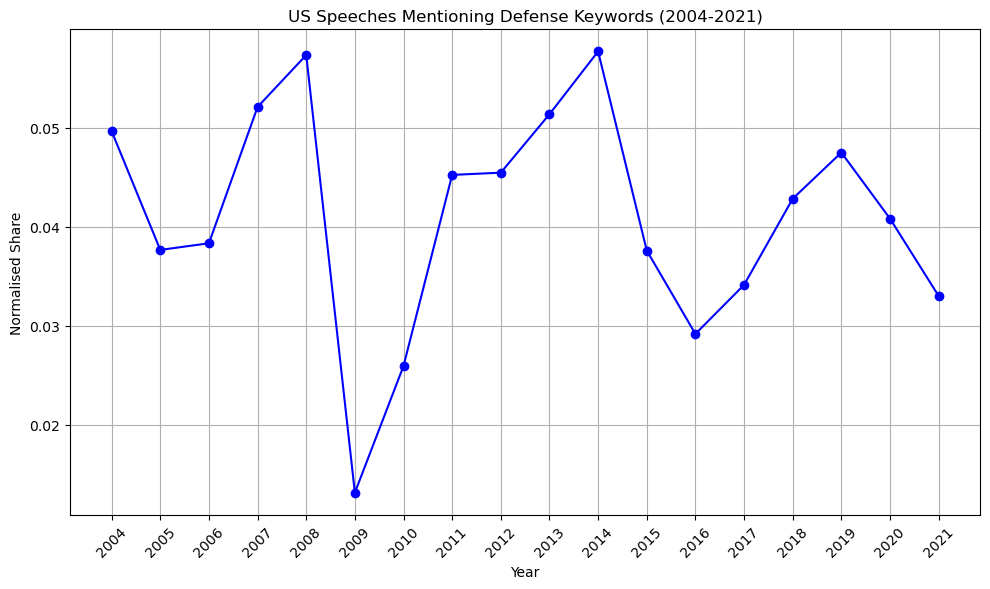

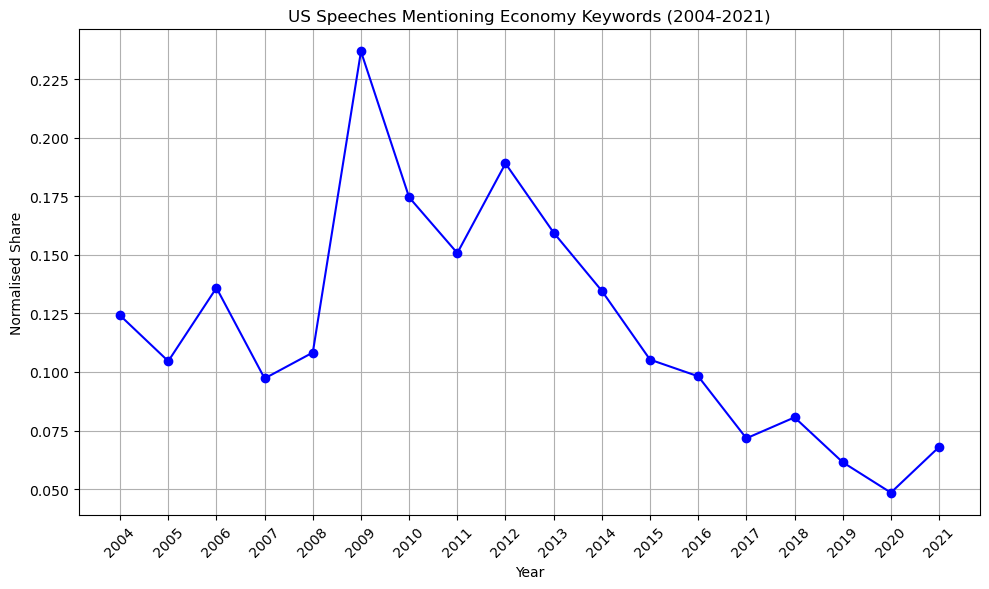

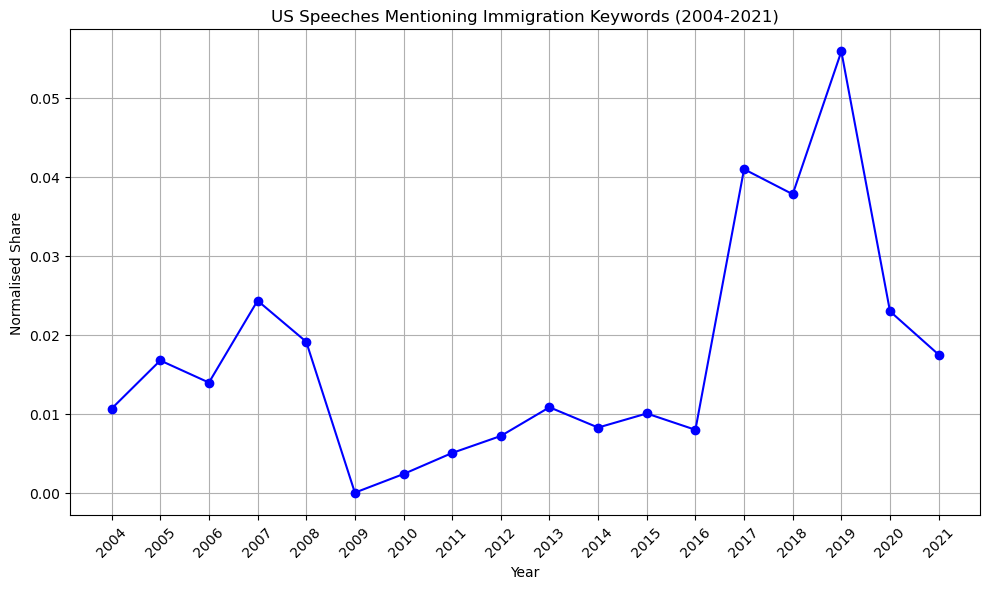

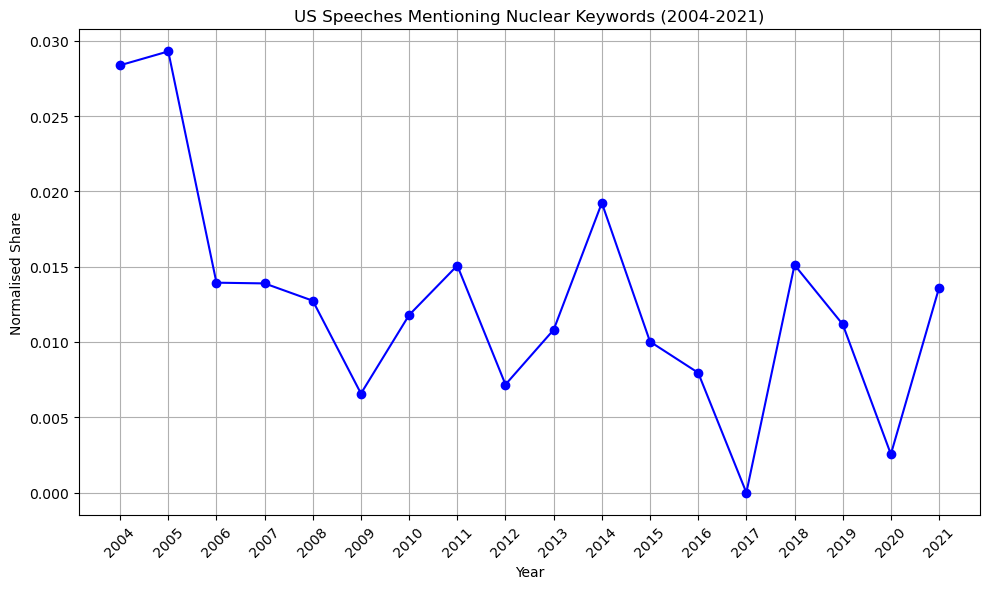

In [22]:
colors = ["blue","red", "green", "orange"]
categories = us_speeches_normalised["category"].unique()

for category in categories:
    df_cat = us_speeches_normalised[us_speeches_normalised["category"] == category]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df_cat["year"], df_cat["normalised_share"], marker="o", color="blue")
    ax.set_xlabel("Year")
    ax.set_ylabel("Normalised Share")
    ax.set_title(f"US Speeches Mentioning {category.capitalize()} Keywords ({YEAR_START}-{YEAR_END})")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)
    plt.tight_layout()
    fig_path = os.path.join("..", "reports", "figures", f"us_{category}_speeches_plot.png")
    fig.savefig(fig_path)
    plt.show()

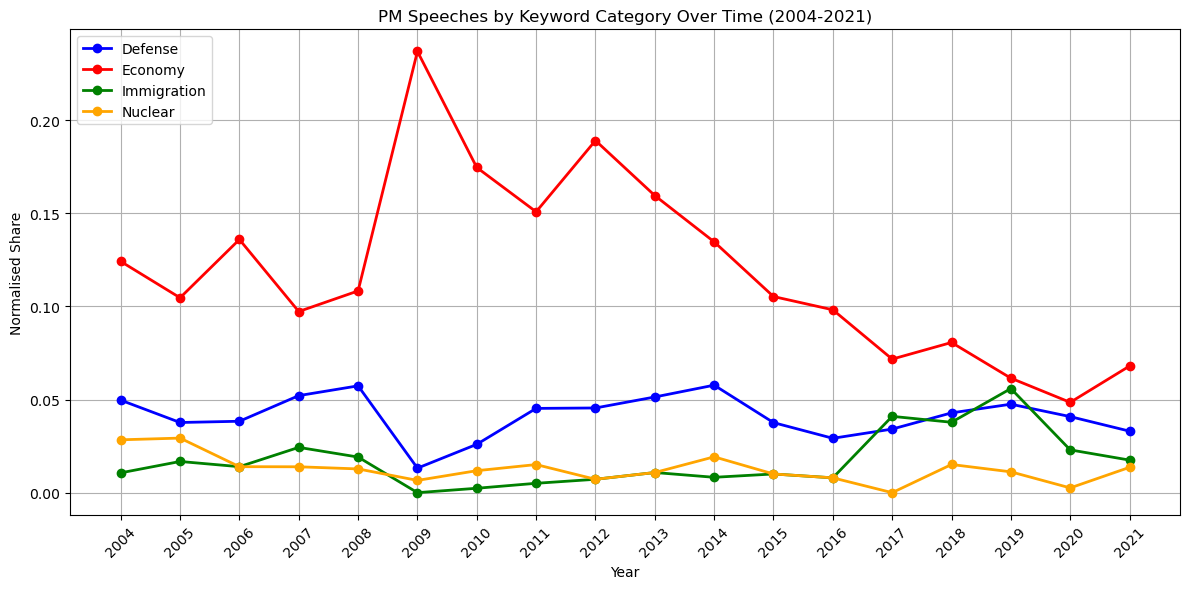

In [23]:
#combined plot for all categories
fig, ax = plt.subplots(figsize=(12, 6))
for category, color in zip(categories, colors[:len(categories)]):
    df_cat = us_speeches_normalised[us_speeches_normalised["category"] == category]
    ax.plot(df_cat["year"], df_cat["normalised_share"], label=category.capitalize(), color=color, marker="o", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Normalised Share")  # ← CHANGE: updated y-axis label
ax.set_title(f"PM Speeches by Keyword Category Over Time ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
%pip install wordcloud
import os
import re
import sys
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud

# CATEGORY_KEYWORDS is normally defined earlier in this notebook.
# Prefer the already-loaded variable; fall back to importing if it's missing.
_CATEGORY_KEYWORDS = globals().get("CATEGORY_KEYWORDS")
if _CATEGORY_KEYWORDS is None:
	try:
		sys.path.append("notebooks")
		from keywords import CATEGORY_KEYWORDS as _CATEGORY_KEYWORDS
	except Exception:
		_CATEGORY_KEYWORDS = {}

# expose as CATEGORY_KEYWORDS for the rest of the notebook
CATEGORY_KEYWORDS = _CATEGORY_KEYWORDS

Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'keywords'

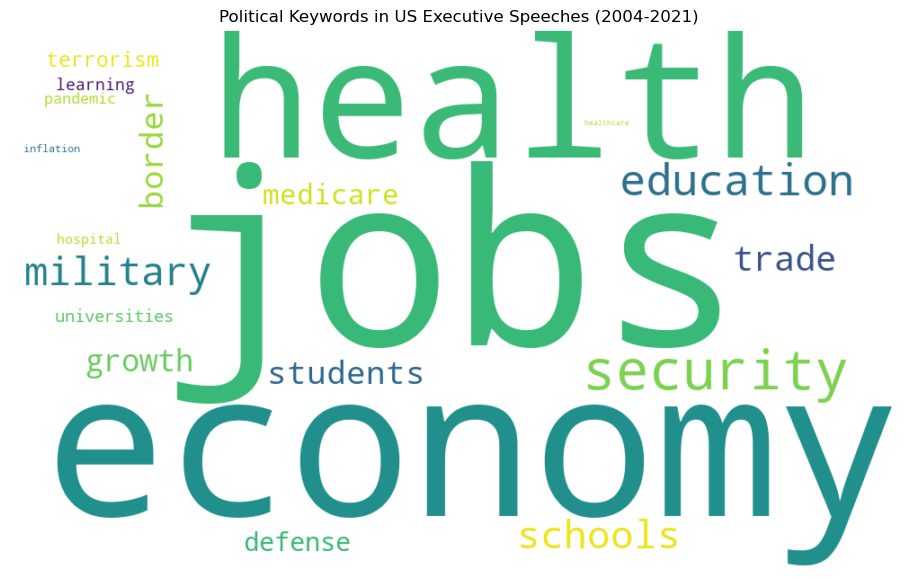

In [34]:
#load clean US data
us_speeches_path = os.path.join("..", "data", "clean", "us_speeches_clean.csv")
df_us = pd.read_csv(us_speeches_path)
YEAR_START, YEAR_END = 2004, 2021
df_us_filtered = df_us[(df_us['year'] >= YEAR_START) & (df_us['year'] <= YEAR_END)]
all_us_text = " ".join(df_us_filtered['text'].astype(str).tolist())
#CATEGORY_KEYWORDS is already defined earlier in the notebook
phrase_frequencies = {}
_category_keywords = globals().get("CATEGORY_KEYWORDS", {})
for category, keywords in _category_keywords.items():
    for keyword in keywords:
        pattern = r"\b" + re.escape(keyword) + r"\b"
        count = len(re.findall(pattern, all_us_text, flags=re.IGNORECASE))
        if count:
            phrase_frequencies[keyword] = count
political_wordcloud = WordCloud(width=1000, height=600, background_color="white").generate_from_frequencies(phrase_frequencies)

plt.figure(figsize=(12, 7))
plt.imshow(political_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Political Keywords in US Executive Speeches ({YEAR_START}-{YEAR_END})")
plt.show()